# Simulate Populations with Spontaneus Birth
## Part 1

There are many events that spontaneusly occur or things that spontaneusly assemble, such as phone calls to a call center, patients admitted to the emergency room, bubbles in a pool of sparkling water, or [protocells][1]. 

### Properties of Spontaneus Birth
Such events or things are assmebled for a period of time bookended by assembly and dissassembly, let's call these birth, life, and death for convenience.

### Purpose

The purpose of this notebook series is to simulate and model this phenomena mathematically to better understand it's physical properties.

### Pretext

Let's focus on protocells, assuming that we have a pool of liquid containing the necessary ingredients and conditions for molecules to spontaneously assemble. 

[1]: https://en.wikipedia.org/wiki/Protocell

In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random

## Build the Simulation

Each protocell is represented by the `entity` object, which has just one property, `period`, to keep track of how many time steps the `entity` (protocell) has survived in the current simulation.

The `environment` class defines the parameters of the environment, which in this simple simulation are just `birth_rate` and `death_chance`. The `environment` class also keeps track of the current population of entities, or protocells 'alive'. When an instance of the `environment` is called, it represents one time step. At each time step, every `entity` currently 'alive' has a chance of 'dying' based on the `death_chance`, and any new `entity` 'born' based on the `birth_rate` is added to the `population` list. `population` represents the current population, while `history` tracks the size of the population through each time step of the simulation.

In [2]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        
        self.population = []
        self.history =[]

    def __call__(self):
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population.append(entity())
        self.history.append(len(self.population))

## Run the Simulation

For now, the simulation is set up so that we can run it step-by-step and observe the change in population, which is printed out as a list. Each protocell currently alive is separated by a coma and the integer value reflects the number of steps, or periods, for which the cell has been alive.

In [3]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1

In [4]:
#Create an instance of environment with chosen parameters
env = environment(birth_rate, death_chance)

In [56]:
# Press CTRL-ENTER to bring the simulation forward by one time step.
env()
env.population

[29, 20, 10, 5, 3, 2, 1, 0]

## Visualize the Simulation's Outcome

After running the simulation several times and observing the population change directly, let's plot the population on a graph to visualize how it has changed over each time step.

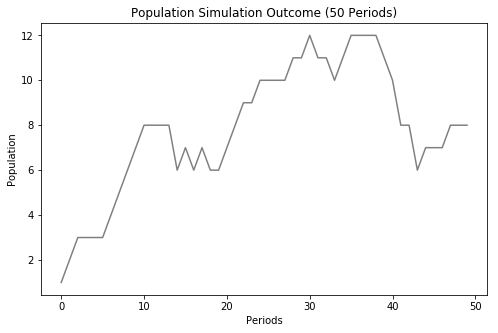

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.set_title(f"Population Simulation Outcome ({len(env.history)} Periods)")
ax.xaxis.set_label_text("Periods")
ax.yaxis.set_label_text("Population")

ax.plot(env.history, color=[.5, .5, .5])
plt.show()

## Conclusion

We can see that the population seems to level off somewhere around 10. However, this is just after a single run, we should run the simulation several more times and extend the length of the simulation - say to 100 periods - to see how it varies. Running the simulation of over 100 periods step-by-step several more times is a bit tedius, so in the next notebook lets create a solution that let's us specify for how many periods we'd like the simulation to run.